Лабораторная работа 2

In [26]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

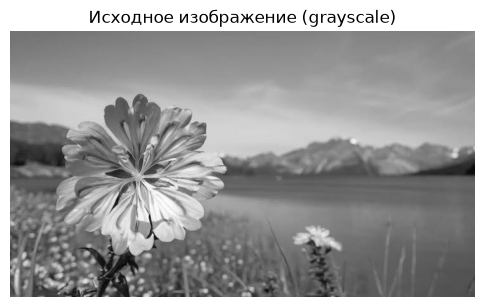

In [27]:
# Загрузка изображения и перевод в оттенки серого
image = cv2.imread('img_task2.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 5))
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение (grayscale)')
plt.axis('off')
plt.show()

In [28]:
# Добавление шума
# Гауса
def add_gaussian_noise(image, mean=0, stddev=25):
    noise = np.zeros(image.shape, np.uint8)
    cv2.randn(noise, mean, stddev)
    noisy = cv2.add(image, noise)
    return noisy

# Соль-перец
def add_salt_pepper_noise(image, prob=0.05):
    noisy = np.copy(image)
    h, w = image.shape
    # Соль (белые точки)
    num_salt = np.ceil(prob * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy[coords[0], coords[1]] = 255
    # Перец (чёрные точки)
    num_pepper = np.ceil(prob * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy[coords[0], coords[1]] = 0
    return noisy

# Равномерный
def add_uniform_noise(image, low=-50, high=50):
    noise = np.random.randint(low, high + 1, size=image.shape, dtype=np.int16)
    noisy = np.clip(image.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return noisy

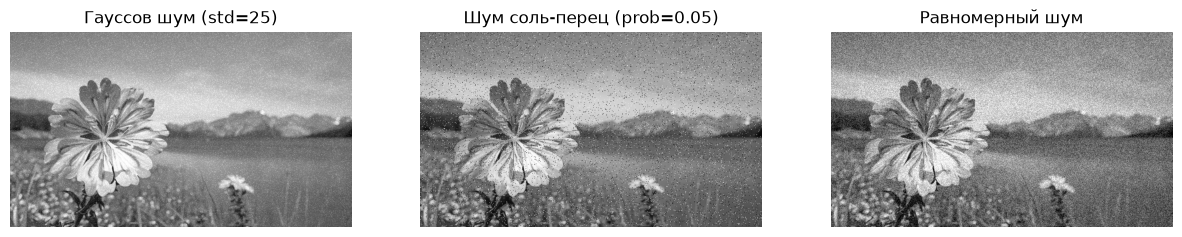

In [29]:
# Генерация
noisy_gauss = add_gaussian_noise(image_gray, mean=0, stddev=25)
noisy_sp = add_salt_pepper_noise(image_gray, prob=0.05)
noisy_uniform = add_uniform_noise(image_gray, low=-50, high=50) 




fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(noisy_gauss, cmap='gray')
axes[0].set_title('Гауссов шум (std=25)')
axes[0].axis('off')
axes[1].imshow(noisy_sp, cmap='gray')
axes[1].set_title('Шум соль-перец (prob=0.05)')
axes[1].axis('off')
axes[2].imshow(noisy_uniform, cmap='gray')    
axes[2].set_title('Равномерный шум')
axes[2].axis('off')
plt.show()

In [30]:
# MSE и SSIIM сравнения
def mse_ssim(original, processed, label=''):
    mse = mean_squared_error(original, processed)
    ssim = structural_similarity(original, processed)
    print(f'{label}: MSE = {mse:.2f}; SSIM = {ssim:.4f}')
    return mse, ssim

Медианный фильтр на гауссовом шуме
Median k=3: MSE = 76.01; SSIM = 0.7739
Median k=5: MSE = 74.14; SSIM = 0.8713
Median k=7: MSE = 100.19; SSIM = 0.8749


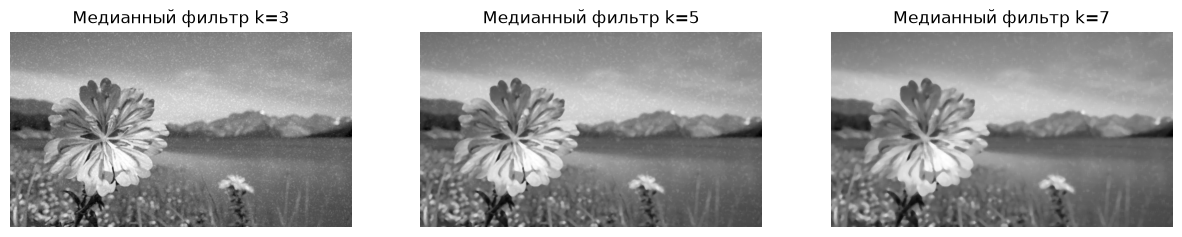


Медианный фильтр на шуме соль-перец
Медианный фильтр k=3: MSE = 11.29; SSIM = 0.9839
Медианный фильтр k=5: MSE = 30.81; SSIM = 0.9567
Медианный фильтр k=7: MSE = 60.25; SSIM = 0.9200


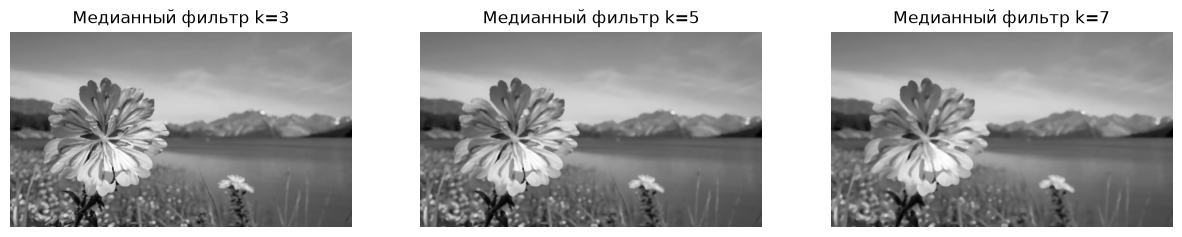

Медианный фильтр на равномерном шуме
Median k=3: MSE = 241.08; SSIM = 0.4031
Median k=5: MSE = 133.12; SSIM = 0.5855
Median k=7: MSE = 122.93; SSIM = 0.6917


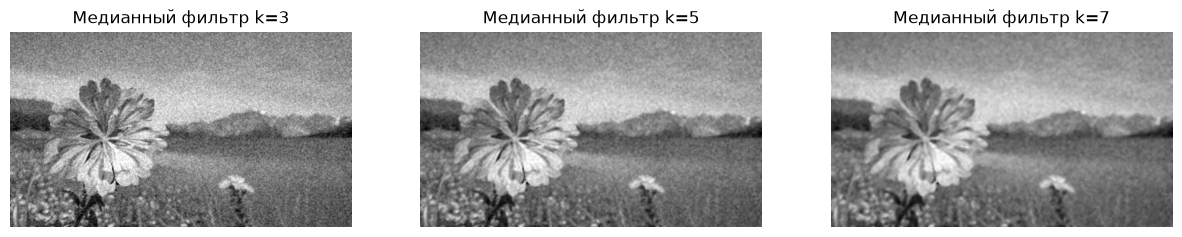

In [31]:
# Медианный фильтр
print("Медианный фильтр на гауссовом шуме")
_, plots = plt.subplots(1, 3, figsize=(15, 5))
for i, k in enumerate([3, 5, 7]):
    filtered = cv2.medianBlur(noisy_gauss, k)
    mse_ssim(image_gray, filtered, f'Median k={k}')
    plots[i].imshow(filtered, cmap='gray')
    plots[i].set_title(f'Медианный фильтр k={k}')
    plots[i].axis('off')
plt.show()

print("\nМедианный фильтр на шуме соль-перец")
_, plots = plt.subplots(1, 3, figsize=(15, 5))
for i, k in enumerate([3, 5, 7]):
    filtered = cv2.medianBlur(noisy_sp, k)
    mse_ssim(image_gray, filtered, f'Медианный фильтр k={k}')
    plots[i].imshow(filtered, cmap='gray')
    plots[i].set_title(f'Медианный фильтр k={k}')
    plots[i].axis('off')
plt.show()

print("Медианный фильтр на равномерном шуме")
_, plots = plt.subplots(1, 3, figsize=(15, 5))
for i, k in enumerate([3, 5, 7]):
    filtered = cv2.medianBlur(noisy_uniform, k)
    mse_ssim(image_gray, filtered, f'Median k={k}')
    plots[i].imshow(filtered, cmap='gray')
    plots[i].set_title(f'Медианный фильтр k={k}')
    plots[i].axis('off')
plt.show()

Фильтр Гаусса на гауссовом шуме
Gaussian k=3: MSE = 138.15; SSIM = 0.7835
Gaussian k=5: MSE = 134.31; SSIM = 0.8562
Gaussian k=7: MSE = 143.56; SSIM = 0.8898


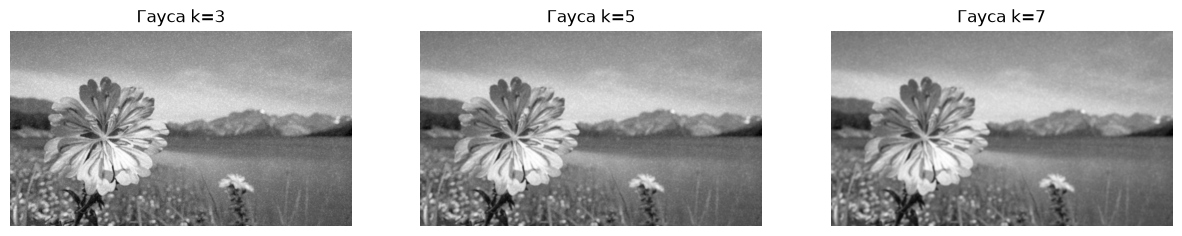


Фильтр Гаусса на шуме соль-перец
Gaussian k=3: MSE = 140.40; SSIM = 0.5665
Gaussian k=5: MSE = 93.70; SSIM = 0.6778
Gaussian k=7: MSE = 80.62; SSIM = 0.7697


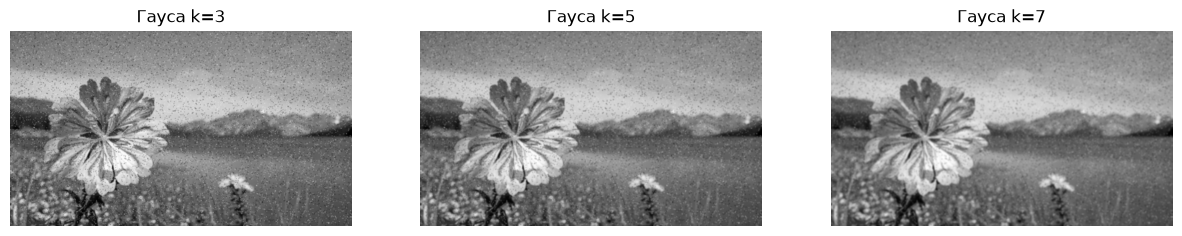


=== Фильтр Гаусса на равномерном шуме ===
Gaussian k=3: MSE = 129.11; SSIM = 0.5318
Gaussian k=5: MSE = 84.36; SSIM = 0.6637
Gaussian k=7: MSE = 71.98; SSIM = 0.7691


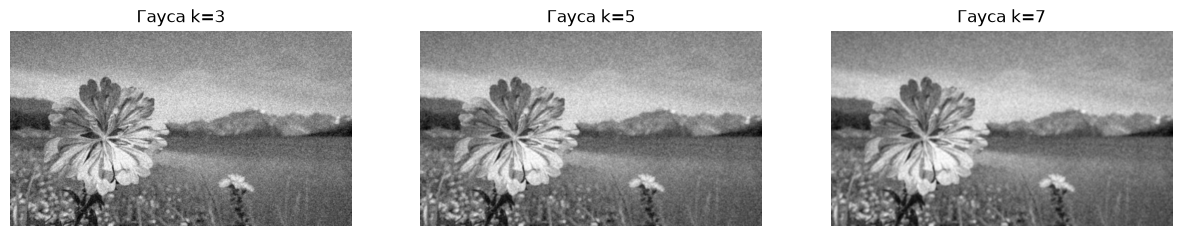

In [32]:
# Фильтр Гаусса
print("Фильтр Гаусса на гауссовом шуме")
_, plots = plt.subplots(1, 3, figsize=(15, 5))
for i, k in enumerate([3, 5, 7]):
    filtered = cv2.GaussianBlur(noisy_gauss, (k, k), 0)
    mse_ssim(image_gray, filtered, f'Gaussian k={k}')
    plots[i].imshow(filtered, cmap='gray')
    plots[i].set_title(f'Гауса k={k}')
    plots[i].axis('off')
plt.show()

print("\nФильтр Гаусса на шуме соль-перец")
_, plots = plt.subplots(1, 3, figsize=(15, 5))
for i, k in enumerate([3, 5, 7]):
    filtered = cv2.GaussianBlur(noisy_sp, (k, k), 0)
    mse_ssim(image_gray, filtered, f'Gaussian k={k}')
    plots[i].imshow(filtered, cmap='gray')
    plots[i].set_title(f'Гауса k={k}')
    plots[i].axis('off')
plt.show()

print("\nФильтр Гаусса на равномерном шуме")
_, plots = plt.subplots(1, 3, figsize=(15, 5))
for i, k in enumerate([3, 5, 7]):
    filtered = cv2.GaussianBlur(noisy_uniform, (k, k), 0)
    mse_ssim(image_gray, filtered, f'Gaussian k={k}')
    plots[i].imshow(filtered, cmap='gray')
    plots[i].set_title(f'Гауса k={k}')
    plots[i].axis('off')
plt.show()

Билатеральный фильтр на гауссовом шуме
Bilateral d=5, sc=75, ss=75: MSE = 115.56; SSIM = 0.8547
Bilateral d=9, sc=75, ss=75: MSE = 143.63; SSIM = 0.8912
Bilateral d=9, sc=150, ss=150: MSE = 168.47; SSIM = 0.8749


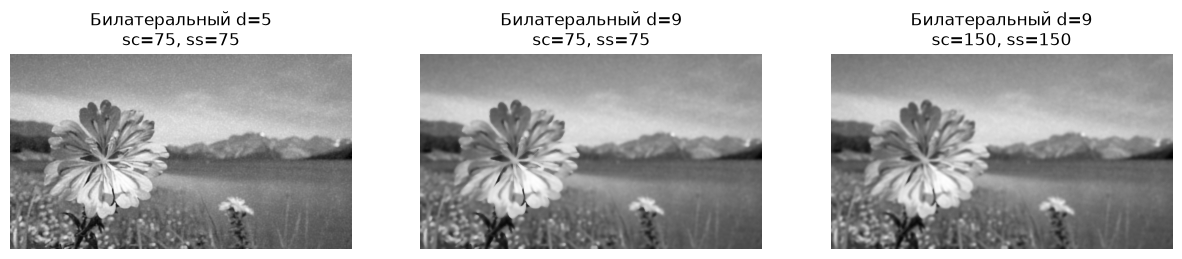


Билатеральный фильтр на шуме соль-перец
Bilateral d=5, sc=75, ss=75: MSE = 272.52; SSIM = 0.5373
Bilateral d=9, sc=75, ss=75: MSE = 174.35; SSIM = 0.6549
Bilateral d=9, sc=150, ss=150: MSE = 82.21; SSIM = 0.8336


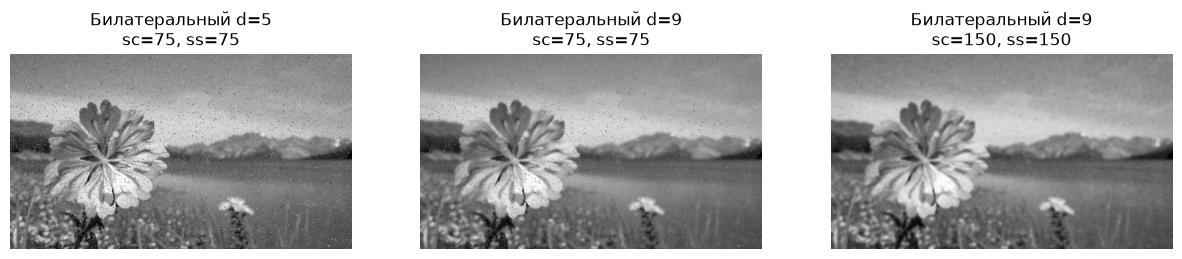


=== Билатеральный фильтр на равномерном шуме ===
Bilateral d=5, sc=75, ss=75: MSE = 106.20; SSIM = 0.5895
Bilateral d=9, sc=75, ss=75: MSE = 82.49; SSIM = 0.7255
Bilateral d=9, sc=150, ss=150: MSE = 85.33; SSIM = 0.8088


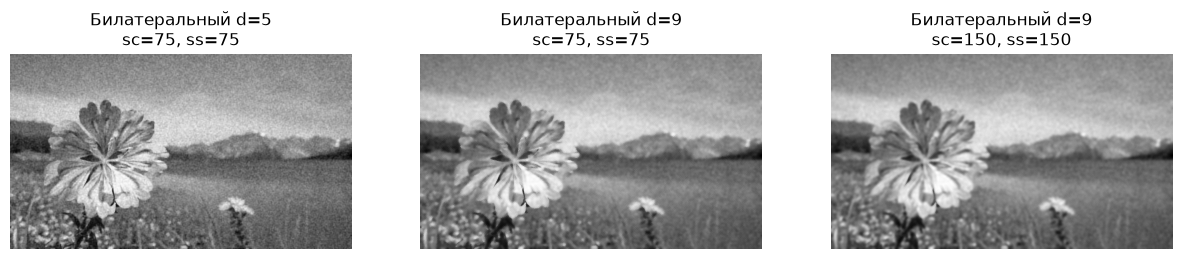

In [33]:
# Билатеральный фильтр
print("Билатеральный фильтр на гауссовом шуме")
params = [(5, 75, 75), (9, 75, 75), (9, 150, 150)]
_, plots = plt.subplots(1, 3, figsize=(15, 5))
for i, (d, sc, ss) in enumerate(params):
    filtered = cv2.bilateralFilter(noisy_gauss, d, sc, ss)
    mse_ssim(image_gray, filtered, f'Bilateral d={d}, sc={sc}, ss={ss}')
    plots[i].imshow(filtered, cmap='gray')
    plots[i].set_title(f'Билатеральный d={d}\nsc={sc}, ss={ss}')
    plots[i].axis('off')
plt.show()

print("\nБилатеральный фильтр на шуме соль-перец")
_, plots = plt.subplots(1, 3, figsize=(15, 5))
for i, (d, sc, ss) in enumerate(params):
    filtered = cv2.bilateralFilter(noisy_sp, d, sc, ss)
    mse_ssim(image_gray, filtered, f'Bilateral d={d}, sc={sc}, ss={ss}')
    plots[i].imshow(filtered, cmap='gray')
    plots[i].set_title(f'Билатеральный d={d}\nsc={sc}, ss={ss}')
    plots[i].axis('off')
plt.show()

print("\nБилатеральный фильтр на равномерном шуме")
params = [(5, 75, 75), (9, 75, 75), (9, 150, 150)]
_, plots = plt.subplots(1, 3, figsize=(15, 5))
for i, (d, sc, ss) in enumerate(params):
    filtered = cv2.bilateralFilter(noisy_uniform, d, sc, ss)
    mse_ssim(image_gray, filtered, f'Bilateral d={d}, sc={sc}, ss={ss}')
    plots[i].imshow(filtered, cmap='gray')
    plots[i].set_title(f'Билатеральный d={d}\nsc={sc}, ss={ss}')
    plots[i].axis('off')
plt.show()

Non-Local Means на гауссовом шуме
NLM h=3: MSE = 306.75; SSIM = 0.4187
NLM h=5: MSE = 306.63; SSIM = 0.4190
NLM h=10: MSE = 153.38; SSIM = 0.8103


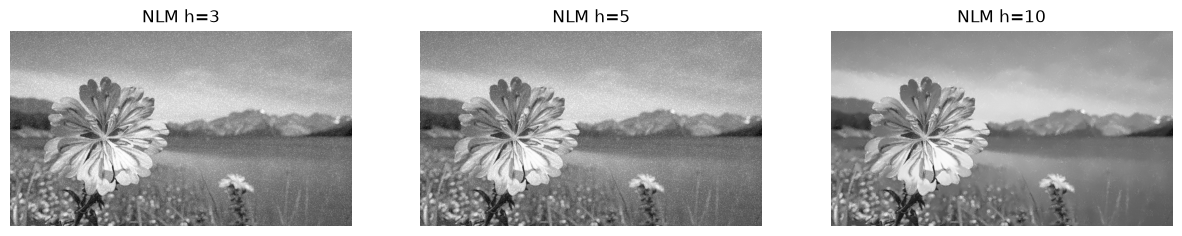


Non-Local Means на шуме соль-перец
NLM h=3: MSE = 884.20; SSIM = 0.2910
NLM h=5: MSE = 883.41; SSIM = 0.2927
NLM h=10: MSE = 848.57; SSIM = 0.3164


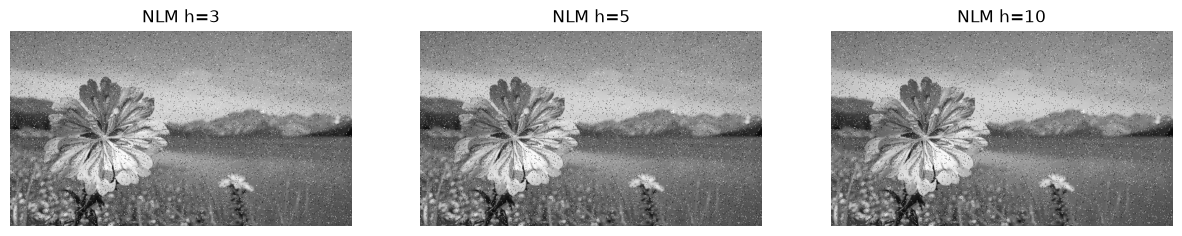


=== Non-Local Means на равномерном шуме ===
NLM h=3: MSE = 840.25; SSIM = 0.2026
NLM h=5: MSE = 840.25; SSIM = 0.2026
NLM h=10: MSE = 840.12; SSIM = 0.2026


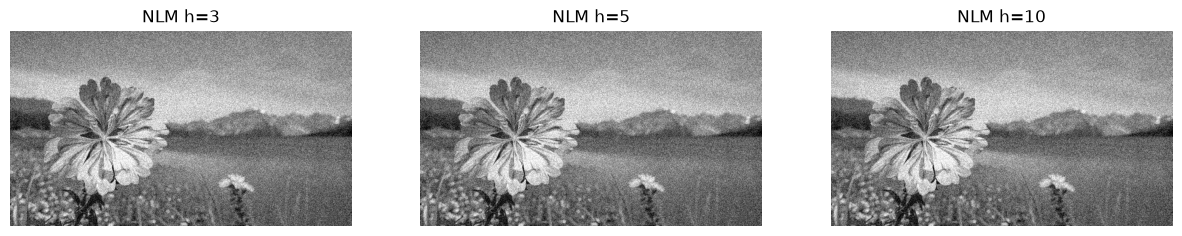

In [34]:
# Фильтр нелокальных средних
print("Non-Local Means на гауссовом шуме")
h_values = [3, 5, 10]
_, plots = plt.subplots(1, 3, figsize=(15, 5))
for i, h in enumerate(h_values):
    filtered = cv2.fastNlMeansDenoising(noisy_gauss, None, h, 7, 21)
    mse_ssim(image_gray, filtered, f'NLM h={h}')
    plots[i].imshow(filtered, cmap='gray')
    plots[i].set_title(f'NLM h={h}')
    plots[i].axis('off')
plt.show()

print("\nNon-Local Means на шуме соль-перец")
_, plots = plt.subplots(1, 3, figsize=(15, 5))
for i, h in enumerate(h_values):
    filtered = cv2.fastNlMeansDenoising(noisy_sp, None, h, 7, 21)
    mse_ssim(image_gray, filtered, f'NLM h={h}')
    plots[i].imshow(filtered, cmap='gray')
    plots[i].set_title(f'NLM h={h}')
    plots[i].axis('off')
plt.show()

print("\nNon-Local Means на равномерном шуме")
_, plots = plt.subplots(1, 3, figsize=(15, 5))
for i, h in enumerate([3, 5, 10]):
    filtered = cv2.fastNlMeansDenoising(noisy_uniform, None, h, 7, 21)
    mse_ssim(image_gray, filtered, f'NLM h={h}')
    plots[i].imshow(filtered, cmap='gray')
    plots[i].set_title(f'NLM h={h}')
    plots[i].axis('off')
plt.show()

In [36]:
noises = [('Соль-перец', noisy_sp), ('Гаусс', noisy_gauss), ('Равномерный', noisy_uniform)]

for label, n in noises:
    results = {
        'Median k=5':    cv2.medianBlur(n, 5),
        'Gaussian k=5':  cv2.GaussianBlur(n, (5,5), 0),
        'Bilateral d=9': cv2.bilateralFilter(n, 9, 75, 75),
        'NLM h=5':       cv2.fastNlMeansDenoising(n, None, 5, 7, 21),
    }

    best, best_mse, best_ssim = None, 999999, 0
    for name, img in results.items():
        mse = mean_squared_error(image_gray, img)
        ssim = structural_similarity(image_gray, img)
        if mse < best_mse:
            best, best_mse, best_ssim = name, mse, ssim

    print(f"{label} → {best} (MSE={best_mse:.1f}, SSIM={best_ssim:.4f})")

Соль-перец → Median k=5 (MSE=30.8, SSIM=0.9567)
Гаусс → Median k=5 (MSE=74.1, SSIM=0.8713)
Равномерный → Bilateral d=9 (MSE=82.5, SSIM=0.7255)
